# Required assignment 12.1: Evaluating acquisition functions

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor #Gaussian Process Regression model. Predicts mean and uncertainty around the prediction
from sklearn.gaussian_process.kernels import RBF # controls smoothness of predictions
from scipy.stats import norm # work with probabilities from normal distribution


## Introduction

This notebook builds on your earlier work with Bayesian optimisation and surrogate models to focus on a key idea: how acquisition functions guide the search for optimal solutions in costly black-box problems. Rather than optimising the true objective directly, the optimiser targets an acquisition function, which is a faster proxy objective that balances exploration and exploitation. These functions use predictions from a surrogate model, such as a Gaussian process (GP), to decide where to sample next.

In this notebook, you’ll investigate popular acquisition functions, including probability of Iiprovement (PI), expected improvement and upper confidence bound (UCB), and consider how their different behaviours affect a model's performance.


### Flow Process: GP --> Acquistion Function--> GP

1. Observe points
2. Fit Gaussian Process
3. Predict mean + uncertainty
4. Acquisition function scores locations
5. Pick best next point
6. Evaluate actual function
7. Update GP
8. Repeat

These acquisition functions are the “decision-making brain” of Bayesian Optimization. First the Gausian process models a function and then acquistion function explores where to look next

### Probability of Improvement (PI)
* Chooses points most likely to improve over the current best result.
> What is the probability this point is better than the best value seen so far?

* PI often prefers regions already known to be good: `A point with slightly higher mean but tiny uncertainty can get high PI.`

* It can get stuck locally.

### Expected Improvement (EI)

* Measures expected amount of improvement. It can answer the question- How much improvement can be expected

* Balances high mean and high uncertainty and is one of the most popular acquistion functions

### Upper Confidence Bound (UCB)

* Explicitly balances mean and uncertainty.Chooses points with higher predicted value or high uncertainity

* Choosing `k` parameter can be tricky

| Acquisition Function | Purpose | Main Idea | Behaviour | Pros | Cons |
|---|---|---|---|---|---|
| **Probability of Improvement (PI)** | Find points that are likely to beat the current best result | Maximizes the probability that a new point improves over the best observed value | Strongly exploitative. Prefers areas already predicted to perform well, even if uncertainty is low | - Simple and intuitive  <br> - Fast convergence in simple problems <br> - Computationally lightweight | - Can get stuck in local optima <br> - Explores very little <br> - Ignores magnitude of improvement <br> - Sensitive to noisy predictions |
| **Expected Improvement (EI)** | Find points expected to give the largest improvement | Balances predicted performance and uncertainty by considering expected amount of improvement | Balanced exploration and exploitation. Naturally explores uncertain regions if they may provide large gains | - Most widely used in practice <br> - Strong balance between exploration and exploitation <br> - Efficient for expensive optimization problems <br> - More globally aware than PI | - Slightly more complex mathematically <br> - Can become exploitative later in optimization <br> - May still under-explore in very complex landscapes |
| **Upper Confidence Bound (UCB)** | Explicitly control exploration vs exploitation | Adds an uncertainty bonus to the predicted mean | Behaviour depends on exploration parameter kappa. Larger kappa → more exploration | - Very interpretable <br> - Easy control over exploration <br> - Strong theoretical guarantees in some settings <br> - Works well in noisy environments | - Performance highly depends on choosing good kappa <br> - Too much exploration can waste evaluations <br> - Requires tuning exploration parameter carefully |

## Acquisition functions

Once the surrogate model is in place, you can optimise an acquisition function to choose the next query point. This optimisation is typically done using gradient-based methods or numerical approaches such as Monte Carlo.

One simple yet effective option is the UCB acquisition function defined as:

$$
\alpha(x | D_n) = m_n(x) + \beta \cdot s_n(x)
$$

where $\beta$ is a parameter that controls the exploration – exploitation trade-off (higher $\beta$ means more exploration). You can then choose the next point using the following rule:

$$
x_{t+1} = \arg\max \alpha(x | D_t)
$$


**Simple Explanation**

Acquisition Functions decide on where to sample next based on :

* predicted value
* uncertainity of prediction

The above two are given by a Gaussian Process and acquistion function uses them to choose the next point

## Hands- on Evaluation


The below creates a random hidden function, uses a Gaussian Process to estimate it from sampled points, uses UCB to choose new points, and finally checks whether Bayesian Optimization found a value close to the true maximum.

| Block                    | Purpose                                                            |
|--------------------------|--------------------------------------------------------------------|
| Setup parameters         | Defines noise, GP smoothness, and UCB exploration strength         |
| Random function creation | Creates a hidden function made of random Gaussian bumps            |
| GP model setup           | Defines the Gaussian Process model using an RBF kernel             |
| Optimization loop        | Repeatedly chooses new x points to evaluate                        |
| Acquisition function     | Uses UCB: mean + beta * uncertainty                                |
| Final evaluation         | Compares Bayesian Optimization result with brute-force grid search |

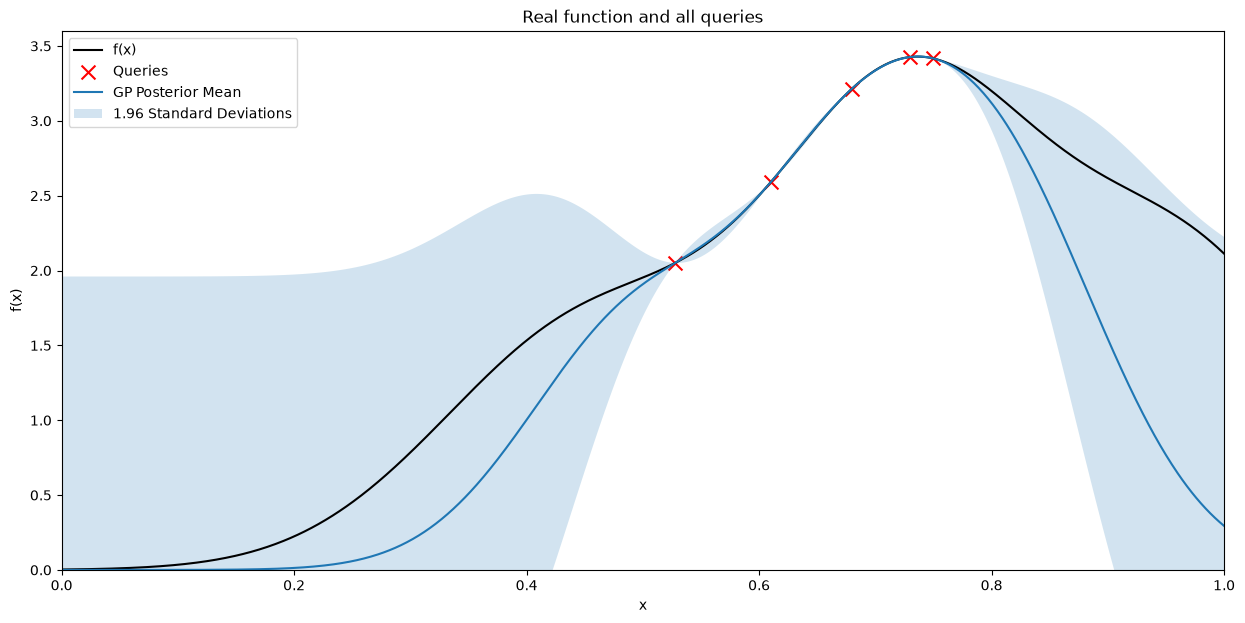

Maximum (by Grid-Search):
3.428870278589523
UCB (Acquisition Function by Grid-Search):
3.4261180488928487


In [2]:
real_noise_std = 1e-10  # actual noise added to function observations
noise_assumption = 1e-10 # gp noise assumed in data

rbf_lengthscale = 0.1 # control smopothness of predictions

#Acquisition function parameter
beta = 1.96 # controls the exploration in UCB

# Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low = 0.005, high = 0.05, size = modes)
means = np.random.uniform(size = modes)
amps = np.random.uniform(size = modes) * (2 - 1) + 1

#Define function
def calc_function(x):
  exp = -(x - means) ** 2 / std
  y = amps * np.exp(exp)
  return np.sum(y)

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

#Define function
def calc_function(x):
  exp = -(x - means) ** 2 / std
  y = amps * np.exp(exp)
  return np.sum(y)
#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0 # best observed values so far
#Initialise grid for plots
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 5

for i in range(0, num_queries):
  #Clear the outputs to keep the interface clean
  clear_output(wait = True)
  model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
  #Fit the model
  if i != 0:
    model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
  #Calculate the mean and standard deviation and make them one-dimensional for plotting
  post_mean, post_std = model.predict(x_grid, return_std=True)
  post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

  #Initialise plots
  fig, ax = plt.subplots(figsize = (15, 7))
  #Set the x and y limits, labels and dynamic title
  ax.set_xlim(0, 1)
  ax.set_ylim(0, max(max_obs + 1, 3))
  ax.set_ylabel('f(x)')
  ax.set_xlabel('x')
  ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.' )
  #Plot queries
  ax.scatter(X, Y, c = 'r', marker='x', s = 100)
  #Plot the mean and standard deviation
  ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
  ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
  ax.legend()
  plt.show()
  #Initialise x
  x = -1
  #Select a display format for X and Y
  X_format =  ['%.2f' % query for query in X] #Two sig figs
  Y_format = ['%.4f' % obs for obs in Y] #Four sig figs

  data = [(query, obs) for query, obs in zip(X_format, Y_format)]
  print('Data so far (sorted by descending observations): ')
  print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
  #_ = input('Input anything to see the next chosen point') #You are using this to allow the user to change plots


  acquisition_function = post_mean + beta * post_std

  if i == 0:
    x = np.random.uniform(0, 1) #The first observation is chosen randomly
  else:
    grid = x_grid.squeeze()
    x = grid[np.argmax(acquisition_function)] #Else use the acquisition function

  #Append data, calculate function and sort lists according to observation values
  X.append(x)
  y = calc_function(x) + np.random.normal(scale = real_noise_std)
  Y.append(y)
  X = [x for _, x in sorted(zip(Y, X), reverse = True)]
  Y.sort(reverse = True)
  max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
  y = calc_function(x)
  y_real.append(y)
  best_obs_grid = max(best_obs_grid, y) #Keep track of the best observation


#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()


#Final plot and display
fig, ax = plt.subplots(figsize = (15, 7))
ax.plot(x_grid, y_real, 'k', label = 'f(x)')
ax.scatter(X, Y, c = 'r', marker = 'x', label = 'Queries', s = 100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(0, 1)
ax.set_ylim(bottom = 0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('UCB (Acquisition Function by Grid-Search):')
print(max_obs)

### Question 1

- Run and re-run the cell until the absolute difference between the true maximum (from grid search) and the best value from acquisition-selected points is **less than 0.01**.

- Capture a screenshot of the graph and submit it separately as your output.

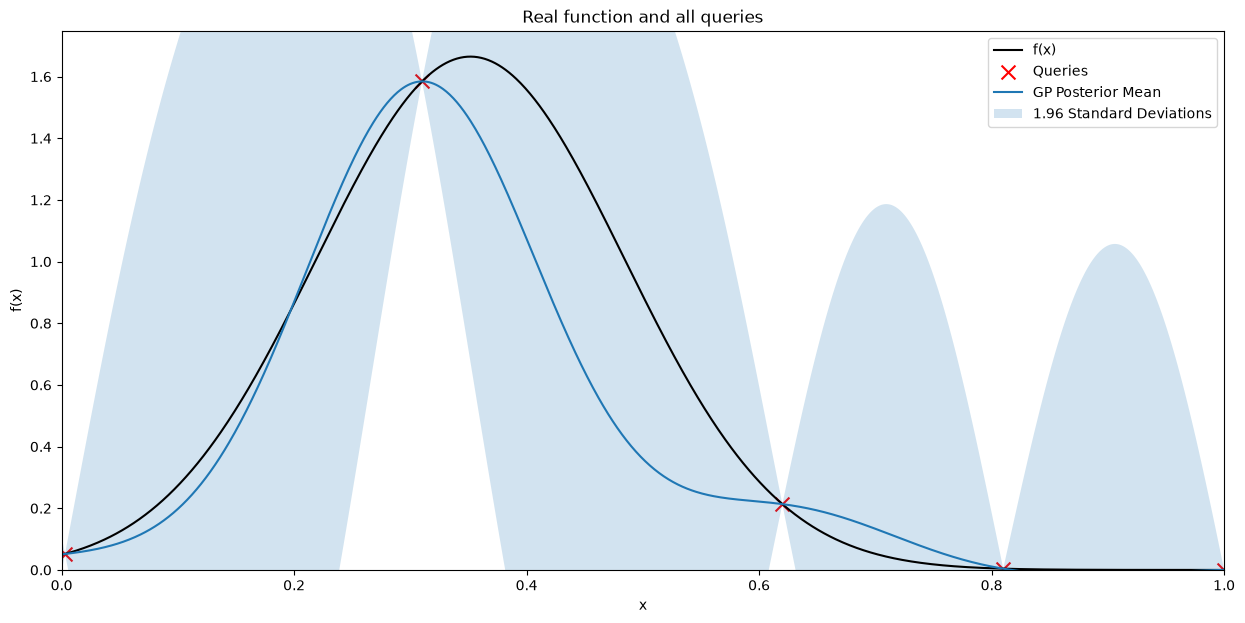

Maximum (by Grid-Search):
1.6647526556185201
UCB (Acquisition Function by Grid-Search):
1.5843366952511202


In [3]:
#Parameters of the problem. Feel free to change them and play around with them.
real_noise_std = 1e-10  #Needs to be positive for code to work, instead of zero set 1e-10
noise_assumption = 1e-10

rbf_lengthscale = 0.1

#Acquisition function parameter (not used for variance-based acquisition)
beta = 1.96

#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

#Define function
def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

#Define the kernel of the GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0
#Initialise grid for plots
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 5

for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait=True)
    model = GaussianProcessRegressor(kernel=kernel)
    #Fit the model
    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    #Initialise plots
    fig, ax = plt.subplots(figsize=(15, 7))
    #Set the x and y limits, labels and dynamic title
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 3))
    ax.set_ylabel('f(x)')
    ax.set_xlabel('x')
    ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.')
    #Plot queries
    ax.scatter(X, Y, c='r', marker='x', s=100)
    #Plot the mean and standard deviation
    ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
    ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha=0.2, label=str(beta) + ' Standard Deviations')
    ax.legend()
    plt.show()
    #Initialise x
    x = -1
    #Select a display format for X and Y
    X_format = ['%.2f' % query for query in X]  #Two sig figs
    Y_format = ['%.4f' % obs for obs in Y]      #Four sig figs

    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start=1)))  #Display data
    #_ = input('Input anything to see the next chosen point')  #You are using this to allow the user to change plots


    acquisition_function = post_std ** 2  #Variance-based acquisition


    if i == 0:
        x = np.random.uniform(0, 1)  #The first observation is chosen randomly
    else:
        grid = x_grid.squeeze()
        x = grid[np.argmax(acquisition_function)]  #Else use the acquisition function

    #Append data, calculate function and sort lists according to observation values
    X.append(x)
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    Y.append(y)
    X = [x for _, x in sorted(zip(Y, X), reverse=True)]
    Y.sort(reverse=True)
    max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
    y = calc_function(x)
    y_real.append(y)
    best_obs_grid = max(best_obs_grid, y)  #Keep track of the best observation

#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

#Final plot and display
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(x_grid, y_real, 'k', label='f(x)')
ax.scatter(X, Y, c='r', marker='x', label='Queries', s=100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha=0.2, label=str(beta) + ' Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('UCB (Acquisition Function by Grid-Search):')
print(max_obs)


### Question 2

PI is an intuitive acquisition function defined as:

$$ \alpha(x)_{PI} = \mathbb{P}(f(x) > y_{max})$$

Here, $y_{max}$ is the best observed value so far.

Now, run and rerun the cell until the absolute difference between the true maximum(from grid search) and the best value from PI-selected points is  **less than 0.01**.

Then, capture a screenshot of this graph and upload it separately onto Canvas as your output.

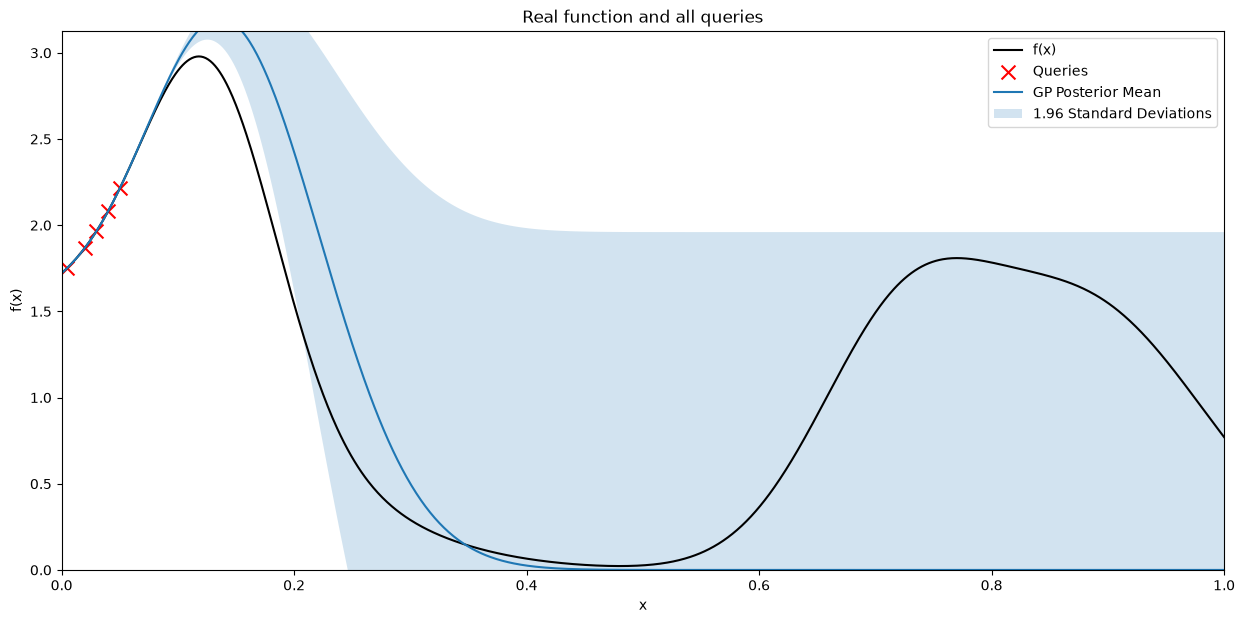

Maximum (by Grid-Search):
2.979107630111963
Best Observation (by PI):
2.212997299855098


In [4]:
###Parameters of the problem. Feel free to change them and play around with them.
real_noise_std = 1e-10  #Needs to be positive for code to work, instead of zero set 1e-10
noise_assumption = 1e-10

rbf_lengthscale = 0.1

#Acquisition function parameter (for PI, this is usually called xi)
xi = 0.01  #You can try 0.01 or 0.05 for more exploration

#Draw a random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

#Define function
def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

#Define the kernel of the GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0
#Initialise grid for plots
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 5

for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait=True)
    model = GaussianProcessRegressor(kernel=kernel)
    #Fit the model
    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    #Initialise plots
    fig, ax = plt.subplots(figsize=(15, 7))
    #Set the x and y limits, labels and dynamic title
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 3))
    ax.set_ylabel('f(x)')
    ax.set_xlabel('x')
    ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.')
    #Plot queries
    ax.scatter(X, Y, c='r', marker='x', s=100)
    #Plot the mean and standard deviation
    ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
    ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, alpha=0.2, label='1.96 Standard Deviations')
    ax.legend()
    plt.show()
    #Initialise x
    x = -1
    #Select a display format for X and Y
    X_format = ['%.2f' % query for query in X]  #Two sig figs
    Y_format = ['%.4f' % obs for obs in Y]      #Four sig figs

    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start=1)))  #Display data
    #_ = input('Input anything to see the next chosen point')  #You are using this to allow the user to change plots


    if i == 0:
        acquisition_function = np.ones_like(post_mean)  #All probabilities are equal for the first point
    else:
        y_max = np.max(Y)
        with np.errstate(divide='warn'):
            z = (post_mean - y_max - xi) / (post_std + 1e-12)  #Add epsilon to avoid division by zero
            acquisition_function = norm.cdf(z)

    if i == 0:
        x = np.random.uniform(0, 1)  #The first observation is chosen randomly
    else:
        grid = x_grid.squeeze()
        x = grid[np.argmax(acquisition_function)]  #Else use the acquisition function

    #Append data, calculate function and sort lists according to observation values
    X.append(x)
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    Y.append(y)
    X = [x for _, x in sorted(zip(Y, X), reverse=True)]
    Y.sort(reverse=True)
    max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
    y = calc_function(x)
    y_real.append(y)
    best_obs_grid = max(best_obs_grid, y)  #Keep track of the best observation

#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

#Final plot and display
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(x_grid, y_real, 'k', label='f(x)')
ax.scatter(X, Y, c='r', marker='x', label='Queries', s=100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, alpha=0.2, label='1.96 Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('Best Observation (by PI):')
print(max_obs)


### Question 3

The PI acquisition function is highly exploitative. To encourage more exploration, you can add a small positive term:

$$ \alpha(x)_{\eta PI} = \mathbb{P}(x > y_{max} + \eta)$$

- Run and re-run the cell until the absolute difference between the true maximum(from grid search) and the best value from PI(with exploration term) is **less than 0.01**.

- Once this condition is met, capture a screenshot of the graph and upload it separately onto Canvas.

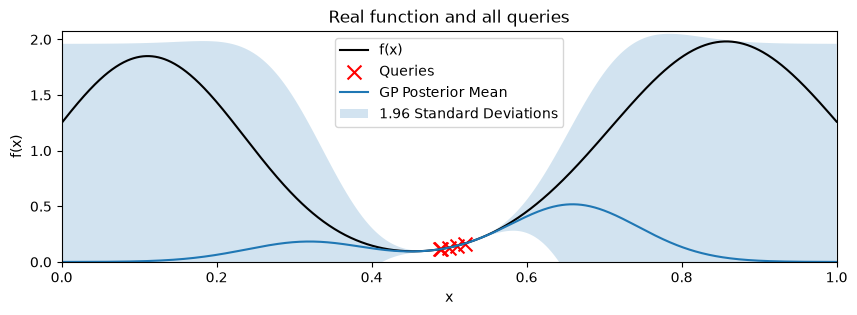

Maximum (by Grid-Search):
1.981477516559884
Best Observation (by PI):
0.16472813928175478


In [5]:

#Parameters of the problem. Feel free to change them and play around with them.
real_noise_std = 1e-10  #Needs to be positive for code to work, instead of zero set 1e-10
noise_assumption = 1e-10

rbf_lengthscale = 0.1

#Acquisition function parameter (for PI, this is usually called xi)
xi = 0.0  #You can try 0.01 or 0.05 for more exploration
eta = 0.0
#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

#Define function
def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

#Define the kernel of the GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0
#Initialise grid for plots
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 5

for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait=True)
    model = GaussianProcessRegressor(kernel=kernel)
    #Fit the model
    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    #Initialise plots
    fig, ax = plt.subplots(figsize=(15, 7))
    #Set the x and y limits, labels and dynamic title
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 3))
    ax.set_ylabel('f(x)')
    ax.set_xlabel('x')
    ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.')
    #Plot queries
    ax.scatter(X, Y, c='r', marker='x', s=100)
    #Plot the mean and standard deviation
    ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
    ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, alpha=0.2, label='1.96 Standard Deviations')
    ax.legend()
    plt.show()
    #Initialise x
    x = -1
    #Select a display format for X and Y
    X_format = ['%.2f' % query for query in X]  #Two sig figs
    Y_format = ['%.4f' % obs for obs in Y]      #Four sig figs

    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start=1)))  #Display data


    if i == 0:
        acquisition_function = np.ones_like(post_mean)  #All probabilities are equal for the first point
    else:
        y_max = np.max(Y)
        with np.errstate(divide='warn'):
            z = (post_mean - y_max - eta) / (post_std + 1e-12)  #Add epsilon to avoid division by zero
            acquisition_function = norm.cdf(z)

    if i == 0:
        x = np.random.uniform(0, 1)  #The first observation is chosen randomly
    else:
        grid = x_grid.squeeze()
        x = grid[np.argmax(acquisition_function)]  #Else use the acquisition function

    #Append data, calculate function and sort lists according to observation values
    X.append(x)
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    Y.append(y)
    X = [x for _, x in sorted(zip(Y, X), reverse=True)]
    Y.sort(reverse=True)
    max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
    y = calc_function(x)
    y_real.append(y)
    best_obs_grid = max(best_obs_grid, y)  #Keep track of the best observation

#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

#Final plot and display
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_grid, y_real, 'k', label='f(x)')
ax.scatter(X, Y, c='r', marker='x', label='Queries', s=100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, alpha=0.2, label='1.96 Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('Best Observation (by PI):')
print(max_obs)
